In [1]:
!pip install numpy matplotlib pillow scikit-image opencv-python

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, filters, transform
from skimage.util import img_as_float

In [4]:
img = data.camera()

print(type(img))
print(img.shape)
print(img.dtype)
print(img.min())
print(img.max())

<class 'numpy.ndarray'>
(512, 512)
uint8
0
255


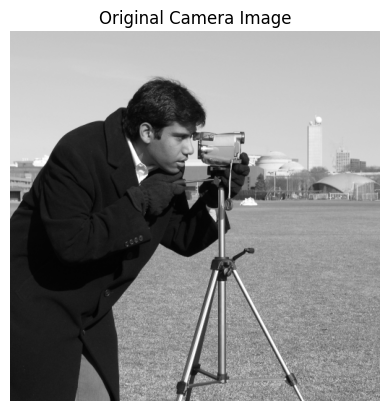

In [5]:
plt.imshow(img, cmap="gray")
plt.title("Original Camera Image")
plt.axis("off")
plt.show()

In [6]:
img_float = img.astype(float) / 255.0

print(img_float.dtype)
print(img_float.min())
print(img_float.max())

float64
0.0
1.0


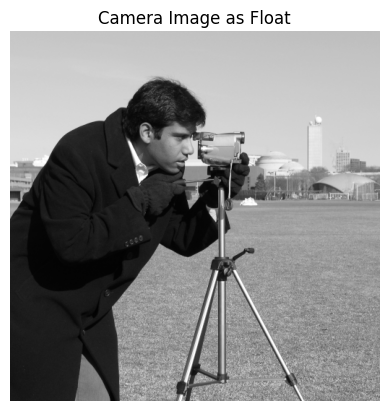

In [7]:
plt.imshow(img_float, cmap="gray")
plt.title("Camera Image as Float")
plt.axis("off")
plt.show()

In [8]:
from skimage import io

my_img = io.imread('/content/drive/MyDrive/DT096A_Lab1/image-1.jpeg')

print(my_img.shape)
print(my_img.dtype)
print(my_img.min())
print(my_img.max())

(1599, 1200, 3)
uint8
0
255


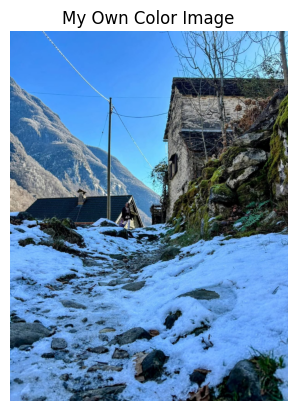

In [9]:
plt.imshow(my_img)
plt.title("My Own Color Image")
plt.axis("off")
plt.show()


#lab task: 3.1 Sampling and Aliasing

Original shape: (512, 512)


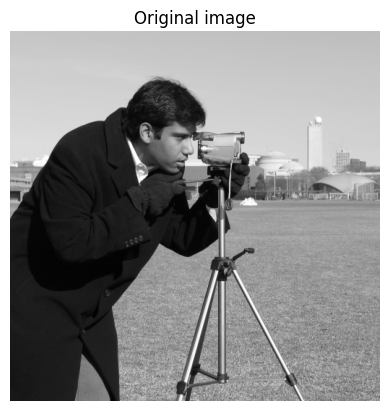

In [10]:
from skimage import data
import matplotlib.pyplot as plt

img = data.camera()

print("Original shape:", img.shape)

plt.imshow(img, cmap="gray")
plt.title("Original image")
plt.axis("off")
plt.show()

Downsampled shape: (256, 256)


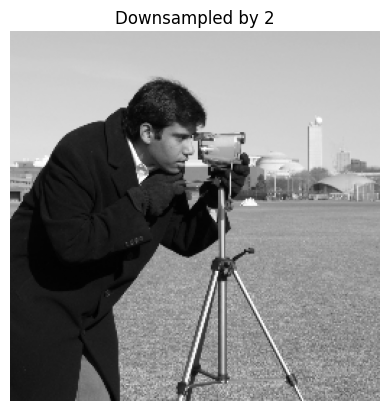

In [11]:
img_down2 = img[::2, ::2]

print("Downsampled shape:", img_down2.shape)

plt.imshow(img_down2, cmap="gray")
plt.title("Downsampled by 2")
plt.axis("off")
plt.show()

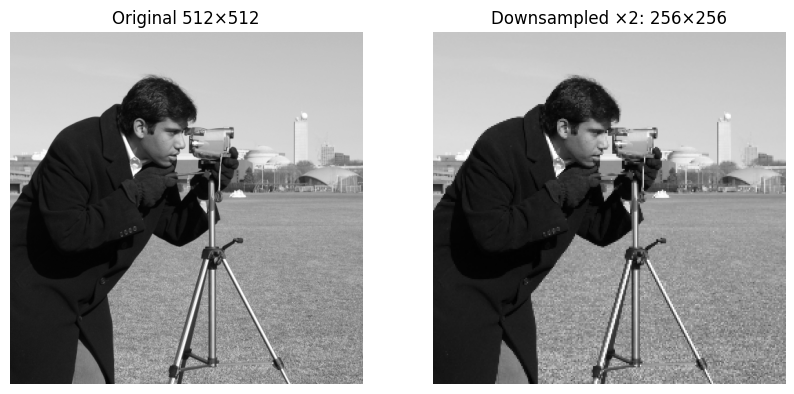

In [12]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original 512×512")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_down2, cmap="gray")
plt.title("Downsampled ×2: 256×256")
plt.axis("off")

plt.show()


In [13]:
img_down4 = img[::4, ::4]
img_down8 = img[::8, ::8]

print("Factor 2:", img_down2.shape)
print("Factor 4:", img_down4.shape)
print("Factor 8:", img_down8.shape)

Factor 2: (256, 256)
Factor 4: (128, 128)
Factor 8: (64, 64)


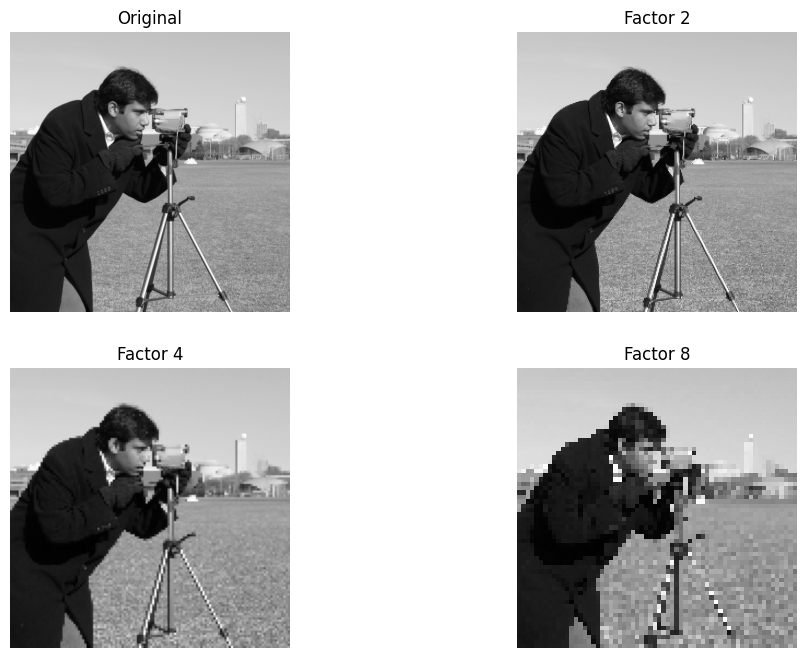

In [14]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img_down2, cmap="gray")
plt.title("Factor 2")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(img_down4, cmap="gray")
plt.title("Factor 4")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_down8, cmap="gray")
plt.title("Factor 8")
plt.axis("off")

plt.show()

In [15]:
img = data.camera().astype(float) / 255.0

In [16]:
def downsample(im, factor, antialias=True):
    if antialias:
        im = filters.gaussian(im, sigma=factor/2)

    h, w = im.shape[:2]

    return transform.resize(
        im,
        (h // factor, w // factor),
        anti_aliasing=False
    )

In [17]:
downsample(img, 2, antialias=False)

array([[0.78333333, 0.78333333, 0.78235294, ..., 0.74411765, 0.74313725,
        0.74509804],
       [0.78235294, 0.78137255, 0.78235294, ..., 0.74411765, 0.74509804,
        0.74509804],
       [0.78333333, 0.78333333, 0.78039216, ..., 0.74705882, 0.74803922,
        0.74803922],
       ...,
       [0.09705882, 0.09901961, 0.09411765, ..., 0.54019608, 0.57352941,
        0.45196078],
       [0.09901961, 0.09901961, 0.1       , ..., 0.55196078, 0.62745098,
        0.57156863],
       [0.09803922, 0.1       , 0.09705882, ..., 0.55882353, 0.58039216,
        0.59803922]])

In [18]:
downsample(img, 2, antialias=True)

array([[0.78313498, 0.78285521, 0.78242825, ..., 0.74367866, 0.74378548,
        0.74475656],
       [0.7825453 , 0.78209815, 0.78206256, ..., 0.74504407, 0.74537532,
        0.74556932],
       [0.7837414 , 0.78272925, 0.7812297 , ..., 0.7471317 , 0.74736939,
        0.74729852],
       ...,
       [0.09806985, 0.09775989, 0.09539709, ..., 0.54578819, 0.5461749 ,
        0.49381925],
       [0.09930078, 0.09847785, 0.09813989, ..., 0.58502769, 0.5854273 ,
        0.56746349],
       [0.09896634, 0.09875294, 0.09690419, ..., 0.58346767, 0.5758869 ,
        0.59118664]])

In [19]:
noaa_2 = downsample(img, 2, antialias=False)
aa_2 = downsample(img, 2, antialias=True)

print("Original:", img.shape)
print("No AA:", noaa_2.shape)
print("With AA:", aa_2.shape)

Original: (512, 512)
No AA: (256, 256)
With AA: (256, 256)


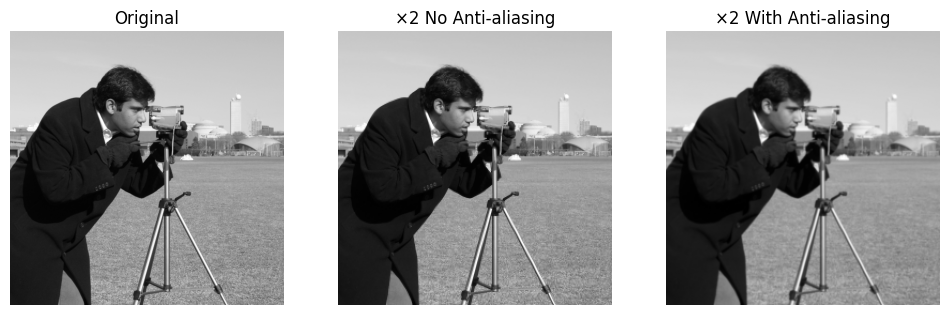

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noaa_2, cmap="gray")
plt.title("×2 No Anti-aliasing")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(aa_2, cmap="gray")
plt.title("×2 With Anti-aliasing")
plt.axis("off")

plt.show()

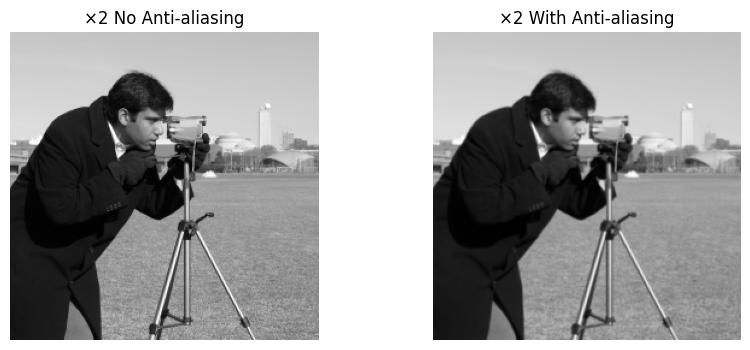

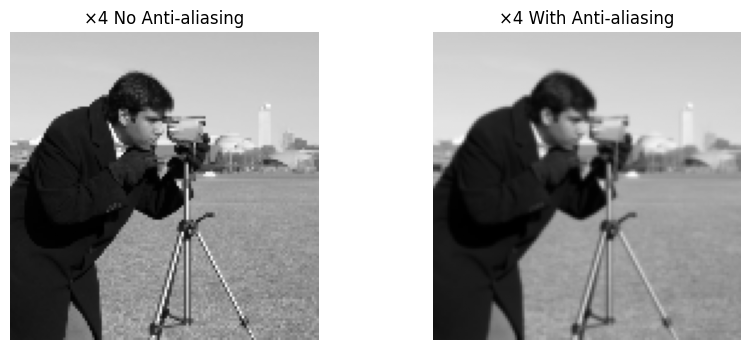

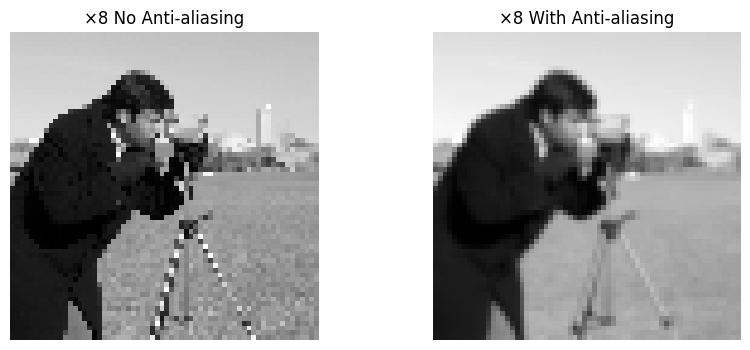

In [21]:
factors = [2, 4, 8]

for f in factors:
    noaa = downsample(img, f, antialias=False)
    aa = downsample(img, f, antialias=True)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(noaa, cmap="gray")
    plt.title(f"×{f} No Anti-aliasing")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(aa, cmap="gray")
    plt.title(f"×{f} With Anti-aliasing")
    plt.axis("off")

    plt.show()

In [22]:
def show_spectrum(im):
    F = np.fft.fftshift(np.fft.fft2(im))
    mag = np.log1p(np.abs(F))

    plt.imshow(mag, cmap='gray')
    plt.title('Magnitude Spectrum')
    plt.axis('off')

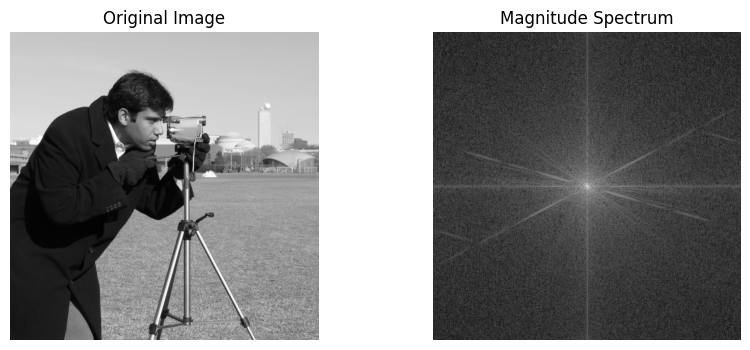

In [23]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
show_spectrum(img)

plt.show()

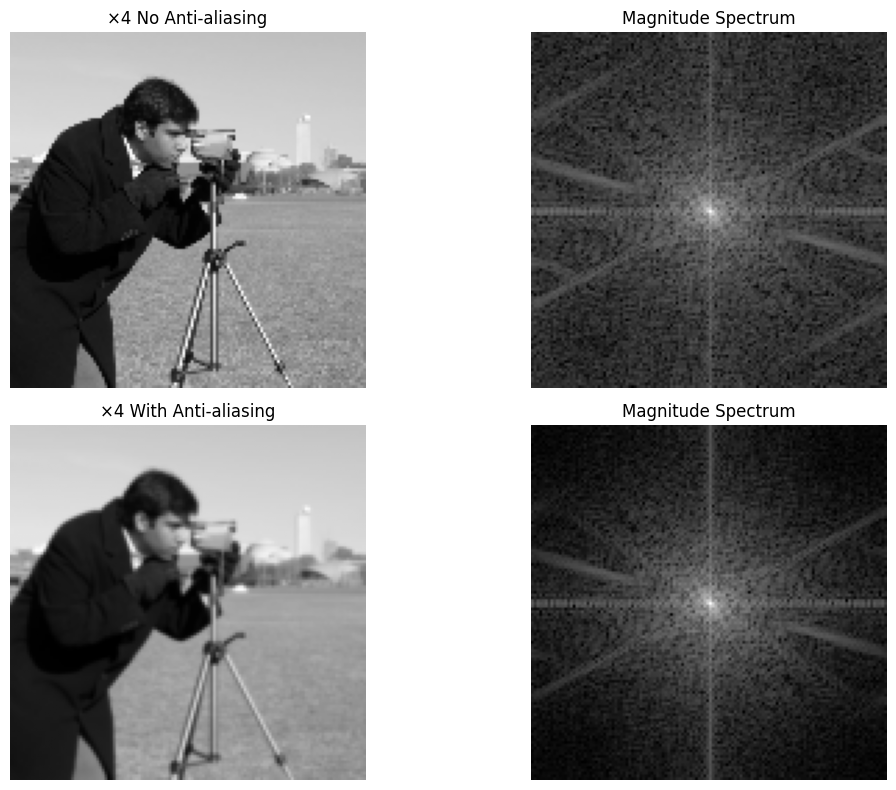

In [24]:
noaa_4 = downsample(img, 4, antialias=False)
aa_4 = downsample(img, 4, antialias=True)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(noaa_4, cmap='gray')
plt.title('×4 No Anti-aliasing')
plt.axis('off')

plt.subplot(2, 2, 2)
show_spectrum(noaa_4)

plt.subplot(2, 2, 3)
plt.imshow(aa_4, cmap='gray')
plt.title('×4 With Anti-aliasing')
plt.axis('off')

plt.subplot(2, 2, 4)
show_spectrum(aa_4)

plt.tight_layout()
plt.show()

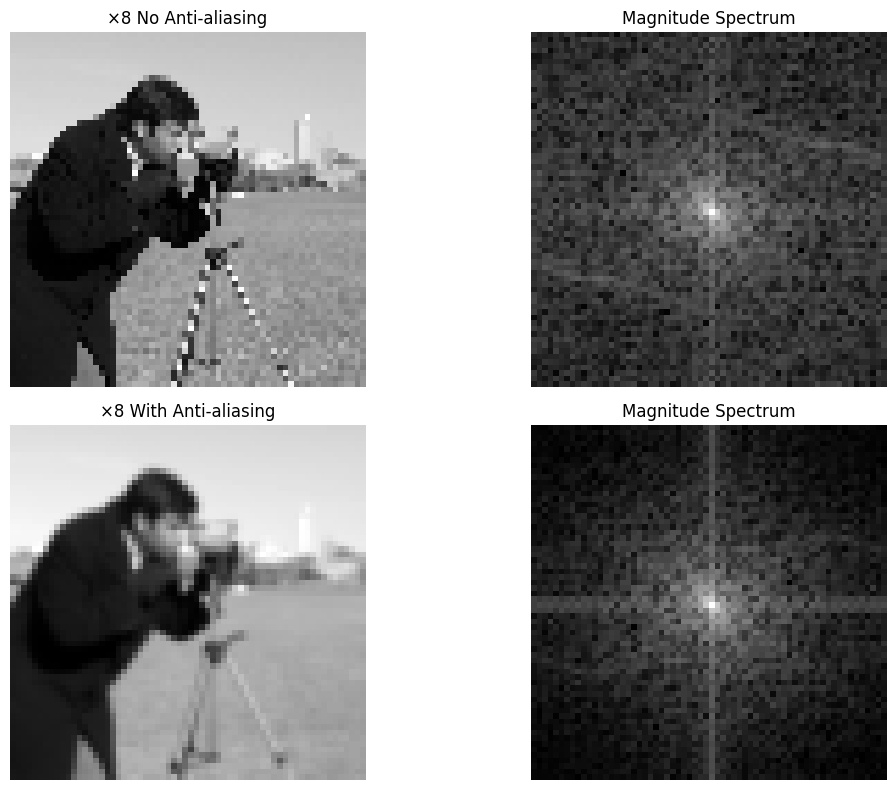

In [25]:
noaa_8 = downsample(img, 8, antialias=False)
aa_8 = downsample(img, 8, antialias=True)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(noaa_8, cmap='gray')
plt.title('×8 No Anti-aliasing')
plt.axis('off')

plt.subplot(2, 2, 2)
show_spectrum(noaa_8)

plt.subplot(2, 2, 3)
plt.imshow(aa_8, cmap='gray')
plt.title('×8 With Anti-aliasing')
plt.axis('off')

plt.subplot(2, 2, 4)
show_spectrum(aa_8)

plt.tight_layout()
plt.show()

#Task 2 of Section 3.1

In [26]:
from skimage import io, color

my_img = io.imread('/content/drive/MyDrive/DT096A_Lab1/image-1.jpeg')

print(my_img.shape)

(1599, 1200, 3)


In [27]:
my_gray = color.rgb2gray(my_img)

print(my_gray.shape)
print(my_gray.min(), my_gray.max())

(1599, 1200)
0.0 0.9994345098039217


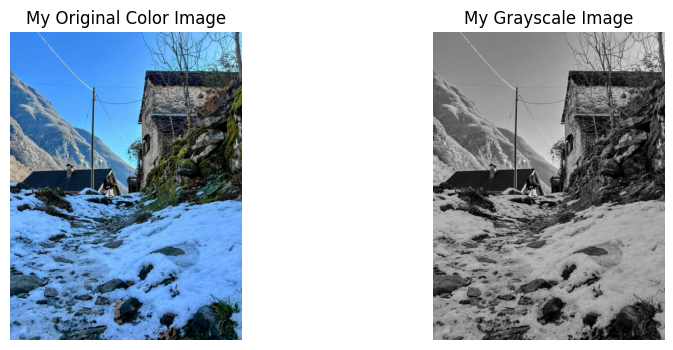

In [28]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(my_img)
plt.title("My Original Color Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(my_gray, cmap="gray")
plt.title("My Grayscale Image")
plt.axis("off")

plt.show()

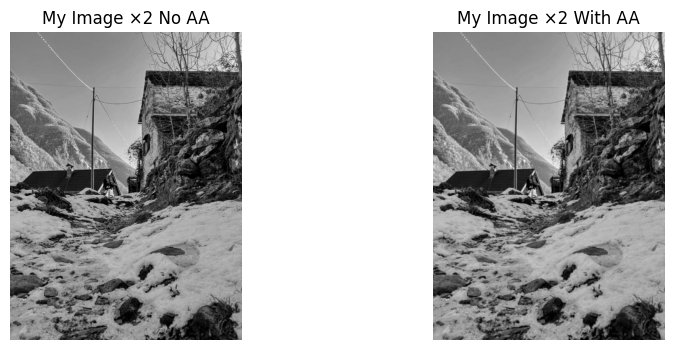

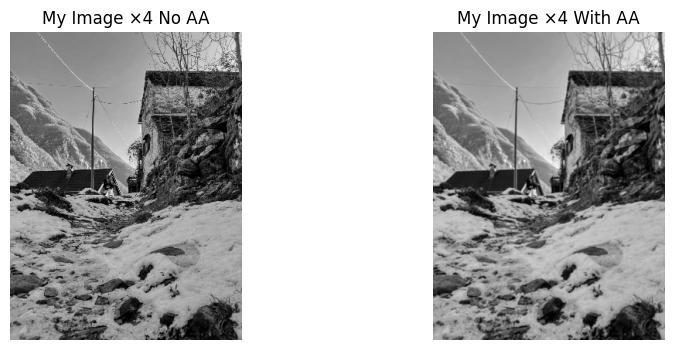

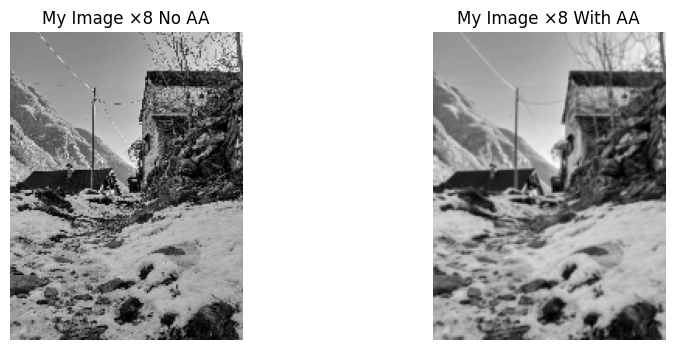

In [29]:
factors = [2, 4, 8]

for f in factors:
    noaa = downsample(my_gray, f, antialias=False)
    aa = downsample(my_gray, f, antialias=True)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(noaa, cmap='gray')
    plt.title(f"My Image ×{f} No AA")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(aa, cmap='gray')
    plt.title(f"My Image ×{f} With AA")
    plt.axis("off")

    plt.show()

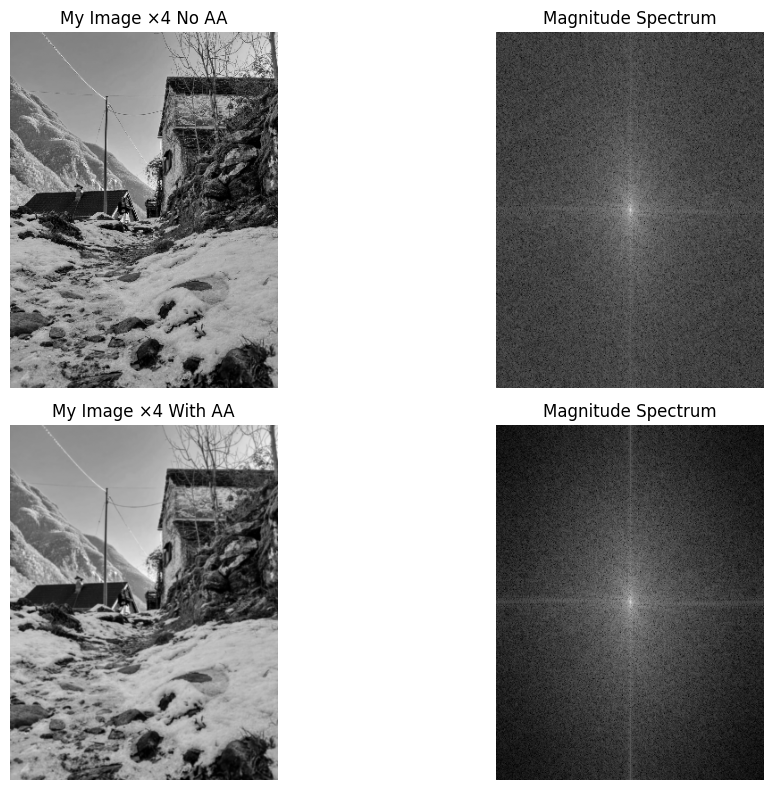

In [30]:
my_noaa_4 = downsample(my_gray, 4, antialias=False)
my_aa_4 = downsample(my_gray, 4, antialias=True)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(my_noaa_4, cmap='gray')
plt.title("My Image ×4 No AA")
plt.axis("off")

plt.subplot(2,2,2)
show_spectrum(my_noaa_4)

plt.subplot(2,2,3)
plt.imshow(my_aa_4, cmap='gray')
plt.title("My Image ×4 With AA")
plt.axis("off")

plt.subplot(2,2,4)
show_spectrum(my_aa_4)

plt.tight_layout()
plt.show()

#3.2 Quantization and SQNR

In [31]:
from skimage import data
from skimage.util import img_as_float

img = img_as_float(data.camera())

print(img.shape)
print(img.min(), img.max())

(512, 512)
0.0 1.0


In [32]:
def quantize01(im01, bits):
    M = 2**bits
    return np.round(np.clip(im01, 0, 1) * (M - 1)) / (M - 1)

In [33]:
q2 = quantize01(img, 2)

print("Original unique values:", len(np.unique(img)))
print("2-bit unique values:", len(np.unique(q2)))

Original unique values: 256
2-bit unique values: 4


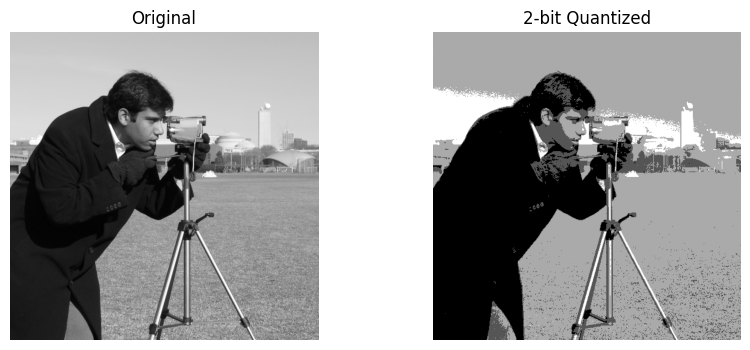

In [34]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(q2, cmap='gray')
plt.title("2-bit Quantized")
plt.axis("off")

plt.show()

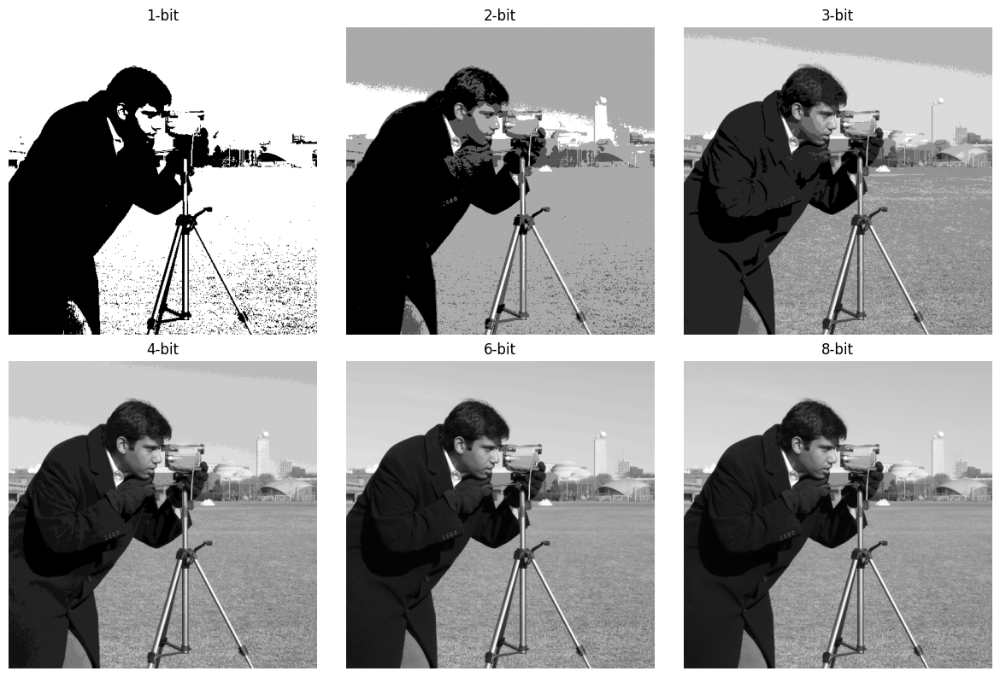

In [35]:
bits_list = [1, 2, 3, 4, 6, 8]

plt.figure(figsize=(12,8))

for i, b in enumerate(bits_list):
    q = quantize01(img, b)

    plt.subplot(2,3,i+1)
    plt.imshow(q, cmap='gray')
    plt.title(f"{b}-bit")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
q = quantize01(img, 2)

err = img - q

print("Minimum error:", err.min())
print("Maximum error:", err.max())

Minimum error: -0.16470588235294115
Maximum error: 0.1647058823529412


In [37]:
mse = np.mean(err**2)

print("MSE:", mse)

MSE: 0.011141684303738348


In [38]:
signal_power = np.mean(img**2)
noise_power = mse

sqnr = 10 * np.log10(signal_power / noise_power)

print("SQNR:", sqnr, "dB")

SQNR: 14.839724711491073 dB


In [39]:
bits_list = [1, 2, 3, 4, 6, 8]

mse_list = []
sqnr_list = []

for b in bits_list:
    q = quantize01(img, b)

    err = img - q
    mse = np.mean(err**2)

    sqnr = 10 * np.log10(
        np.mean(img**2) / mse
    )

    mse_list.append(mse)
    sqnr_list.append(sqnr)

    print(
        f"{b} bits -> MSE = {mse:.6f}, SQNR = {sqnr:.2f} dB"
    )

1 bits -> MSE = 0.078856, SQNR = 6.34 dB
2 bits -> MSE = 0.011142, SQNR = 14.84 dB
3 bits -> MSE = 0.001876, SQNR = 22.58 dB
4 bits -> MSE = 0.000409, SQNR = 29.19 dB
6 bits -> MSE = 0.000021, SQNR = 42.17 dB
8 bits -> MSE = 0.000000, SQNR = 327.55 dB


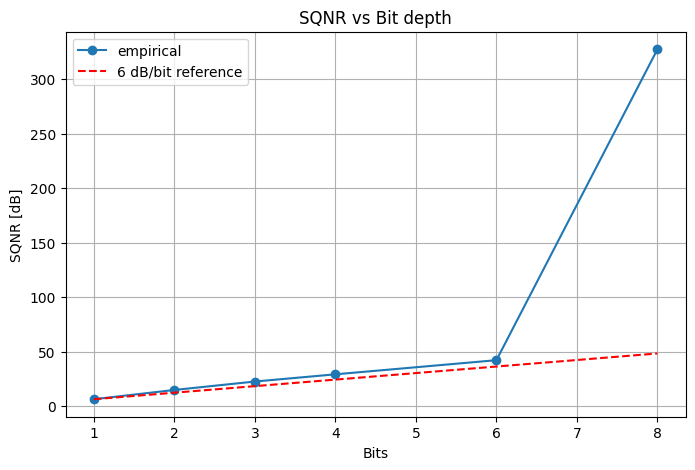

In [42]:
ref = sqnr_list[0] + 6 * (
    np.array(bits_list) - bits_list[0]
)

plt.figure(figsize=(8,5))

plt.plot(
    bits_list,
    sqnr_list,
    'o-',
    label='empirical'
)

plt.plot(
    bits_list,
    ref,
    'r--',
    label='6 dB/bit reference'
)

plt.xlabel('Bits')
plt.ylabel('SQNR [dB]')
plt.title('SQNR vs Bit depth')
plt.legend()
plt.grid()

plt.show()

#Section 3.2

In [43]:
my_img = io.imread('/content/drive/MyDrive/DT096A_Lab1/image-1.jpeg')

In [44]:
my_color = img_as_float(my_img)

print(my_color.shape)
print(my_color.min(), my_color.max())

(1599, 1200, 3)
0.0 1.0


In [45]:
q2_color = quantize01(my_color, 2)
q4_color = quantize01(my_color, 4)
q8_color = quantize01(my_color, 8)

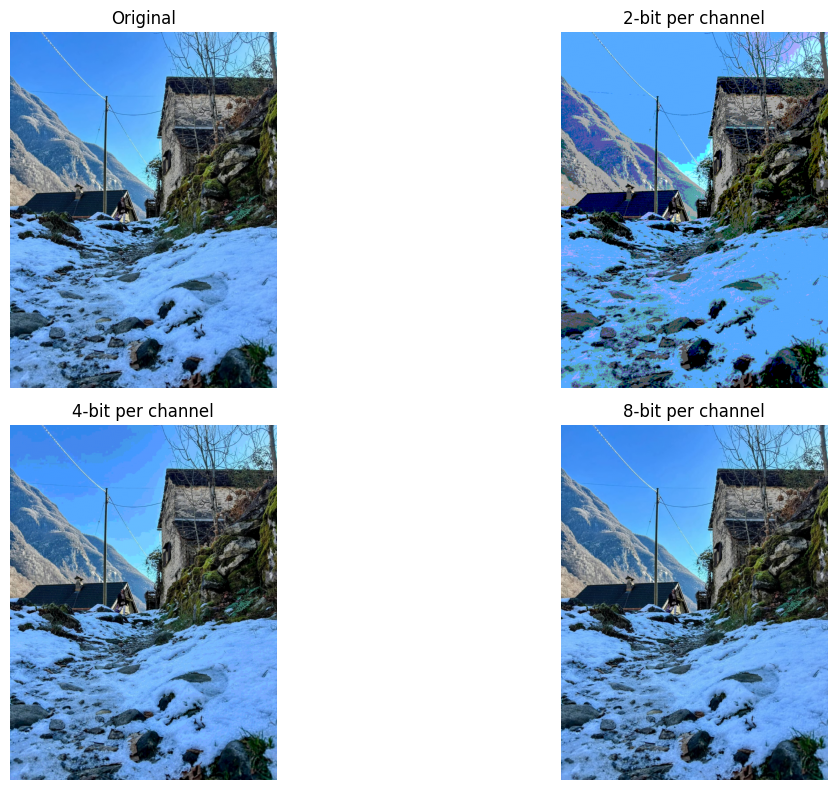

In [46]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(my_color)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(q2_color)
plt.title("2-bit per channel")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(q4_color)
plt.title("4-bit per channel")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(q8_color)
plt.title("8-bit per channel")
plt.axis("off")

plt.tight_layout()
plt.show()

In [47]:
bits_list = [1, 2, 3, 4, 6, 8]

color_mse = []
color_sqnr = []

for b in bits_list:
    q = quantize01(my_color, b)

    err = my_color - q
    mse = np.mean(err**2)

    sqnr = 10 * np.log10(
        np.mean(my_color**2) / mse
    )

    color_mse.append(mse)
    color_sqnr.append(sqnr)

    print(
        f"{b} bits -> MSE = {mse:.6f}, SQNR = {sqnr:.2f} dB"
    )

1 bits -> MSE = 0.091037, SQNR = 5.42 dB
2 bits -> MSE = 0.007790, SQNR = 16.10 dB
3 bits -> MSE = 0.001537, SQNR = 23.15 dB
4 bits -> MSE = 0.000355, SQNR = 29.51 dB
6 bits -> MSE = 0.000021, SQNR = 41.85 dB
8 bits -> MSE = 0.000000, SQNR = 328.54 dB


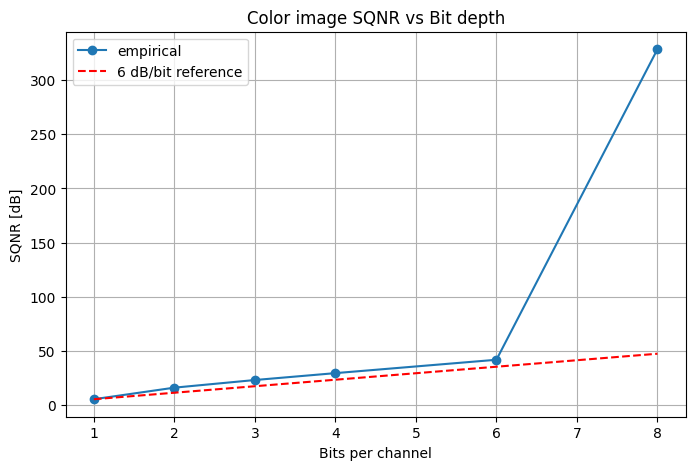

In [50]:
ref_color = color_sqnr[0] + 6 * (
    np.array(bits_list) - bits_list[0]
)

plt.figure(figsize=(8,5))

plt.plot(
    bits_list,
    color_sqnr,
    'o-',
    label='empirical'
)

plt.plot(
    bits_list,
    ref_color,
    'r--',
    label='6 dB/bit reference'
)

plt.xlabel('Bits per channel')
plt.ylabel('SQNR [dB]')
plt.title('Color image SQNR vs Bit depth')
plt.legend()
plt.grid()

plt.show()

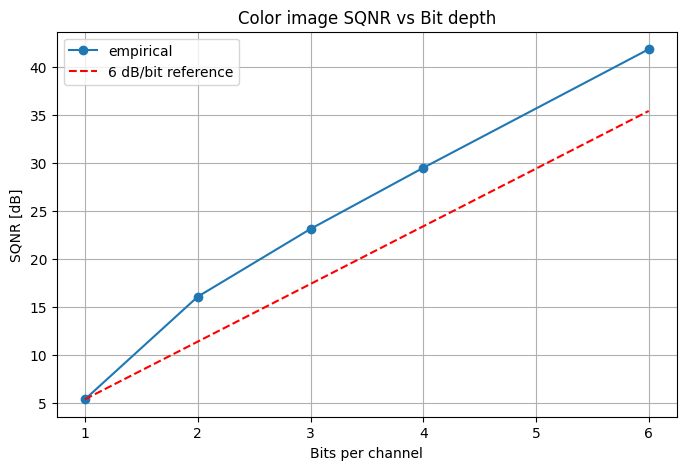

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    bits_list[:-1],
    color_sqnr[:-1],
    'o-',
    label='empirical'
)

plt.plot(
    bits_list[:-1],
    ref_color[:-1],
    'r--',
    label='6 dB/bit reference'
)

plt.xlabel('Bits per channel')
plt.ylabel('SQNR [dB]')
plt.title('Color image SQNR vs Bit depth')
plt.legend()
plt.grid()
plt.show()

#Section 3.3

In [53]:
from skimage import io, color, transform
import numpy as np
import matplotlib.pyplot as plt

my_img = io.imread('/content/drive/MyDrive/DT096A_Lab1/image-1.jpeg')
my_img_float = my_img / 255.0

In [54]:
ycbcr = color.rgb2ycbcr(my_img_float)

print("Shape:", ycbcr.shape)
print("Y range:", ycbcr[:, :, 0].min(), ycbcr[:, :, 0].max())
print("Cb range:", ycbcr[:, :, 1].min(), ycbcr[:, :, 1].max())
print("Cr range:", ycbcr[:, :, 2].min(), ycbcr[:, :, 2].max())

Shape: (1599, 1200, 3)
Y range: 16.0 234.8041882352941
Cb range: 86.74645490196079 191.3997960784314
Cr range: 78.43253333333334 143.81176470588235


In [55]:
Y = ycbcr[:, :, 0]
Cb = ycbcr[:, :, 1]
Cr = ycbcr[:, :, 2]

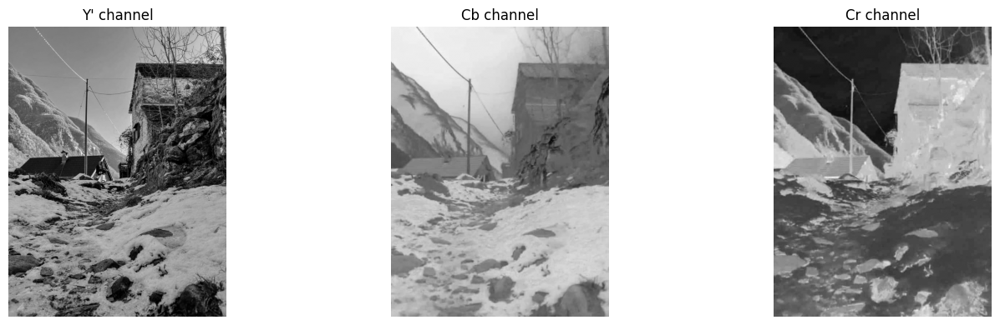

In [60]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(Y, cmap='gray')
plt.title("Y' channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Cb, cmap='gray')
plt.title("Cb channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Cr, cmap='gray')
plt.title("Cr channel")
plt.axis("off")

plt.tight_layout()
plt.show()

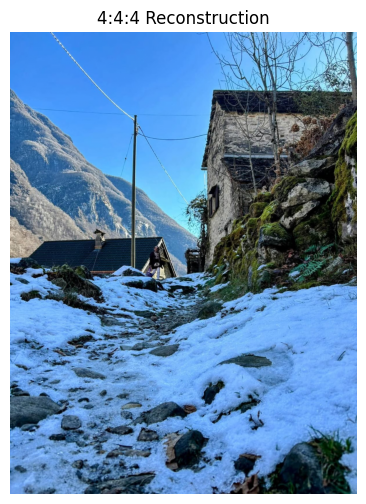

In [57]:
recon_444 = color.ycbcr2rgb(ycbcr)

plt.figure(figsize=(8, 6))
plt.imshow(np.clip(recon_444, 0, 1))
plt.title("4:4:4 Reconstruction")
plt.axis("off")
plt.show()

In [58]:
def subsample_422(C):
    # handle odd width if needed
    if C.shape[1] % 2 != 0:
        C = C[:, :-1]

    return 0.5 * (C[:, 0::2] + C[:, 1::2])

In [59]:
Cb_422 = subsample_422(Cb)
Cr_422 = subsample_422(Cr)

print("Original Cb shape:", Cb.shape)
print("4:2:2 Cb shape:", Cb_422.shape)

Original Cb shape: (1599, 1200)
4:2:2 Cb shape: (1599, 600)


In [61]:
Cb_422_up = transform.resize(
    Cb_422,
    Y.shape,
    anti_aliasing=True
)

Cr_422_up = transform.resize(
    Cr_422,
    Y.shape,
    anti_aliasing=True
)

In [62]:
ycbcr_422 = np.stack(
    [Y, Cb_422_up, Cr_422_up],
    axis=2
)

In [63]:
recon_422 = color.ycbcr2rgb(ycbcr_422)

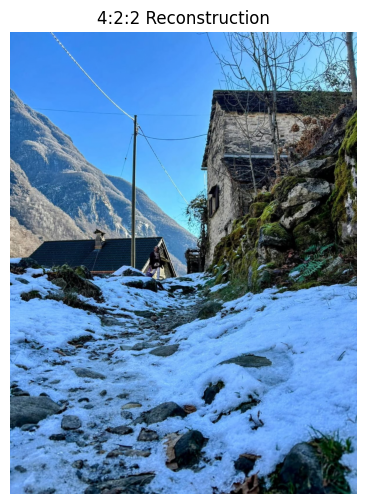

In [64]:
plt.figure(figsize=(8, 6))
plt.imshow(np.clip(recon_422, 0, 1))
plt.title("4:2:2 Reconstruction")
plt.axis("off")
plt.show()

In [66]:
def subsample_420(C):
    h = C.shape[0] - (C.shape[0] % 2)
    w = C.shape[1] - (C.shape[1] % 2)

    C = C[:h, :w]

    return 0.25 * (
        C[0::2, 0::2] +
        C[0::2, 1::2] +
        C[1::2, 0::2] +
        C[1::2, 1::2]
    )

In [67]:
Cb_420 = subsample_420(Cb)
Cr_420 = subsample_420(Cr)

print("Original Cb shape:", Cb.shape)
print("4:2:0 Cb shape:", Cb_420.shape)

Original Cb shape: (1599, 1200)
4:2:0 Cb shape: (799, 600)


In [68]:
Cb_420_up = transform.resize(
    Cb_420,
    Y.shape,
    anti_aliasing=True
)

Cr_420_up = transform.resize(
    Cr_420,
    Y.shape,
    anti_aliasing=True
)

In [69]:
ycbcr_420 = np.stack(
    [Y, Cb_420_up, Cr_420_up],
    axis=2
)

In [70]:
recon_420 = color.ycbcr2rgb(ycbcr_420)

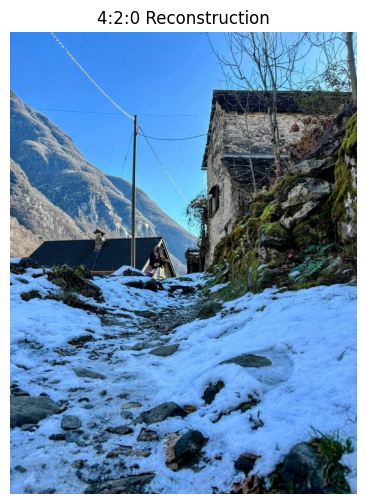

In [71]:
plt.figure(figsize=(8, 6))
plt.imshow(np.clip(recon_420, 0, 1))
plt.title("4:2:0 Reconstruction")
plt.axis("off")
plt.show()

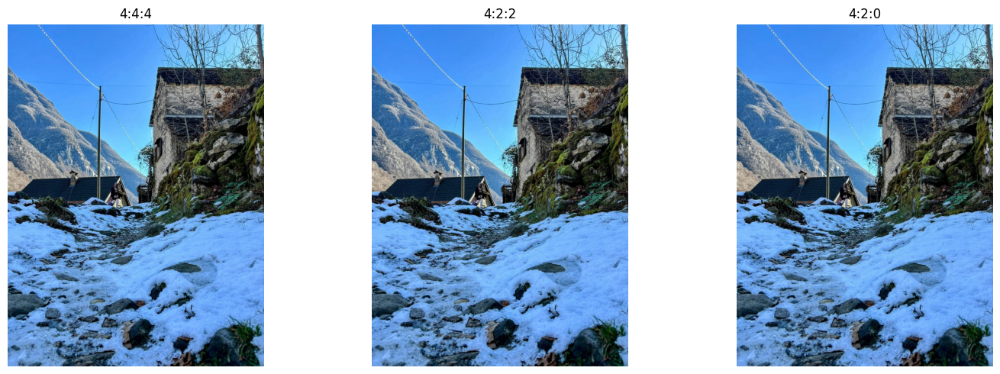

In [72]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(np.clip(recon_444, 0, 1))
plt.title("4:4:4")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.clip(recon_422, 0, 1))
plt.title("4:2:2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.clip(recon_420, 0, 1))
plt.title("4:2:0")
plt.axis("off")

plt.tight_layout()
plt.show()

#Section 4: Information Theory

In [73]:
import numpy as np

def entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

In [76]:

# Fair and biased dice
pf = np.ones(6) / 6
pb = np.array([0.10, 0.20, 0.10, 0.20, 0.20, 0.20])

Hf = entropy(pf)
Hb = entropy(pb)

print("Fair die entropy:", Hf)
print("Biased die entropy:", Hb)

# Joint entropy of two independent fair dice
Pxy = np.ones((6, 6)) / 36
Hxy = entropy(Pxy.ravel())

print("H(X) + H(Y):", Hf + Hf)
print("H(X,Y):", Hxy)

# i.i.d. sequence experiment
N = 100000

seq_fair = np.random.choice(np.arange(1, 7), size=N, p=pf)
counts = np.bincount(seq_fair, minlength=7)[1:]
p_emp = counts / counts.sum()
H_emp = entropy(p_emp)

print("Theoretical fair entropy:", Hf)
print("Empirical fair entropy:", H_emp)

# Correlated sequence
rho = 0.8

seq_corr = np.zeros(N, dtype=int)
seq_corr[0] = np.random.choice(np.arange(1, 7), p=pf)

for t in range(1, N):
    if np.random.rand() < rho:
        seq_corr[t] = seq_corr[t - 1]
    else:
        seq_corr[t] = np.random.choice(np.arange(1, 7), p=pf)

counts_corr = np.bincount(seq_corr, minlength=7)[1:]
p_corr = counts_corr / counts_corr.sum()
H_corr = entropy(p_corr)

joint_counts = np.zeros((6, 6))

for t in range(1, N):
    prev = seq_corr[t - 1] - 1
    curr = seq_corr[t] - 1
    joint_counts[prev, curr] += 1

P_joint = joint_counts / joint_counts.sum()

H_joint = entropy(P_joint.ravel())
P_prev = P_joint.sum(axis=1)
H_prev = entropy(P_prev)

H_cond = H_joint - H_prev

print("Marginal entropy H(X_t):", H_corr)
print("Conditional entropy H(X_t | X_t-1):", H_cond)

Fair die entropy: 2.584962500721156
Biased die entropy: 2.5219280948873624
H(X) + H(Y): 5.169925001442312
H(X,Y): 5.169925001442311
Theoretical fair entropy: 2.584962500721156
Empirical fair entropy: 2.5849349102246153
Marginal entropy H(X_t): 2.584478264749089
Conditional entropy H(X_t | X_t-1): 1.0367107268434657


#4.2

Camera image entropy: 7.231695011055704
My image entropy: 7.495163206400456


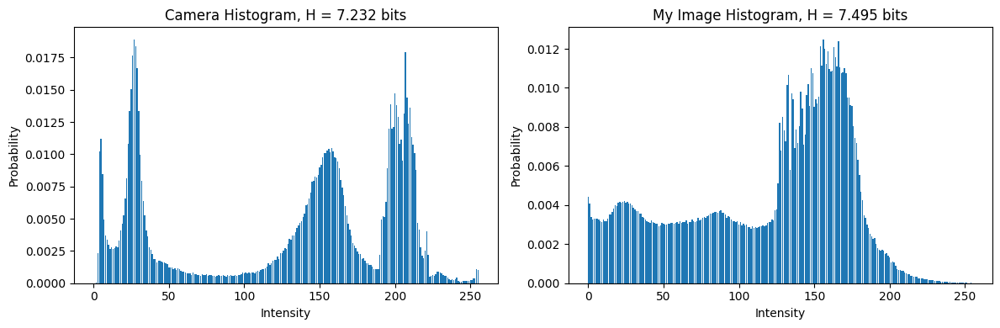

In [77]:
from skimage import data, color, io
import numpy as np
import matplotlib.pyplot as plt

# Images
img1 = data.camera()

my_img = io.imread('/content/drive/MyDrive/DT096A_Lab1/image-1.jpeg')
img2 = color.rgb2gray(my_img)

# Convert second image to 8-bit grayscale
img2_uint8 = (img2 * 255).astype(np.uint8)

def image_entropy_uint8(im):
    counts, _ = np.histogram(im, bins=256, range=(0, 256))
    p = counts / counts.sum()
    return entropy(p), p

H1, p1 = image_entropy_uint8(img1)
H2, p2 = image_entropy_uint8(img2_uint8)

print("Camera image entropy:", H1)
print("My image entropy:", H2)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(np.arange(256), p1)
plt.title(f"Camera Histogram, H = {H1:.3f} bits")
plt.xlabel("Intensity")
plt.ylabel("Probability")

plt.subplot(1, 2, 2)
plt.bar(np.arange(256), p2)
plt.title(f"My Image Histogram, H = {H2:.3f} bits")
plt.xlabel("Intensity")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()

In [78]:
# 4.2 Sequence Experiments

N = 100000

# ----- i.i.d. sequence from image histogram -----

seq_iid = np.random.choice(
    np.arange(256),
    size=N,
    p=p2
)

counts_iid = np.bincount(seq_iid, minlength=256)
p_iid = counts_iid / counts_iid.sum()

H_iid = entropy(p_iid)

print("Original image entropy:", H2)
print("Empirical i.i.d. entropy:", H_iid)


# ----- Correlated intensity sequence -----

rho = 0.8

seq_corr_img = np.zeros(N, dtype=int)

seq_corr_img[0] = np.random.choice(
    np.arange(256),
    p=p2
)

for t in range(1, N):
    if np.random.rand() < rho:
        seq_corr_img[t] = seq_corr_img[t - 1]
    else:
        seq_corr_img[t] = np.random.choice(
            np.arange(256),
            p=p2
        )


# Marginal entropy
counts_corr = np.bincount(seq_corr_img, minlength=256)
p_corr = counts_corr / counts_corr.sum()

H_corr_img = entropy(p_corr)


# Joint probability of consecutive values
joint_counts = np.zeros((256, 256))

for t in range(1, N):
    prev = seq_corr_img[t - 1]
    curr = seq_corr_img[t]

    joint_counts[prev, curr] += 1

P_joint = joint_counts / joint_counts.sum()

H_joint = entropy(P_joint.ravel())

P_prev = P_joint.sum(axis=1)
H_prev = entropy(P_prev)

H_cond_img = H_joint - H_prev

print("Marginal entropy H(X):", H_corr_img)
print("Conditional entropy H(X_t | X_t-1):", H_cond_img)

Original image entropy: 7.495163206400456
Empirical i.i.d. entropy: 7.488992974392178
Marginal entropy H(X): 7.482354830543473
Conditional entropy H(X_t | X_t-1): 1.9427753714468068


In [79]:
# 4.3 Joint and Conditional Entropy

# Use horizontally adjacent pixels from your grayscale image
X = img2_uint8[:, :-1].ravel()
Y = img2_uint8[:, 1:].ravel()

# Joint histogram P(X,Y)
joint_counts, _, _ = np.histogram2d(
    X,
    Y,
    bins=256,
    range=[[0, 256], [0, 256]]
)

PXY = joint_counts / joint_counts.sum()

# Marginal distributions
PX = PXY.sum(axis=1)
PY = PXY.sum(axis=0)

# Entropies
HX = entropy(PX)
HY = entropy(PY)
HXY = entropy(PXY.ravel())

# Conditional entropy H(Y|X)
HY_given_X = HXY - HX

# Mutual information I(X;Y)
I_XY = HY - HY_given_X

print("H(X):", HX)
print("H(Y):", HY)
print("H(X,Y):", HXY)
print("H(Y|X):", HY_given_X)
print("I(X;Y):", I_XY)


# --------------------------------------------------
# Sequence Experiment 1: Independent random pairs
# --------------------------------------------------

N = 100000

X_ind = np.random.randint(0, 256, size=N)
Y_ind = np.random.randint(0, 256, size=N)

joint_ind, _, _ = np.histogram2d(
    X_ind,
    Y_ind,
    bins=256,
    range=[[0, 256], [0, 256]]
)

PXY_ind = joint_ind / joint_ind.sum()

PX_ind = PXY_ind.sum(axis=1)
PY_ind = PXY_ind.sum(axis=0)

HX_ind = entropy(PX_ind)
HY_ind = entropy(PY_ind)
HXY_ind = entropy(PXY_ind.ravel())

HY_given_X_ind = HXY_ind - HX_ind
I_ind = HY_ind - HY_given_X_ind

print("\nIndependent sequences:")
print("H(X):", HX_ind)
print("H(Y):", HY_ind)
print("H(X,Y):", HXY_ind)
print("H(Y|X):", HY_given_X_ind)
print("I(X;Y):", I_ind)


# --------------------------------------------------
# Sequence Experiment 2: Correlated random pairs
# --------------------------------------------------

rho = 0.8

X_corr = np.random.randint(0, 256, size=N)
Y_corr = np.random.randint(0, 256, size=N)

mask = np.random.rand(N) < rho
Y_corr[mask] = X_corr[mask]

joint_corr, _, _ = np.histogram2d(
    X_corr,
    Y_corr,
    bins=256,
    range=[[0, 256], [0, 256]]
)

PXY_corr = joint_corr / joint_corr.sum()

PX_corr = PXY_corr.sum(axis=1)
PY_corr = PXY_corr.sum(axis=0)

HX_corr = entropy(PX_corr)
HY_corr = entropy(PY_corr)
HXY_corr = entropy(PXY_corr.ravel())

HY_given_X_corr = HXY_corr - HX_corr
I_corr = HY_corr - HY_given_X_corr

print("\nCorrelated sequences:")
print("H(X):", HX_corr)
print("H(Y):", HY_corr)
print("H(X,Y):", HXY_corr)
print("H(Y|X):", HY_given_X_corr)
print("I(X;Y):", I_corr)

H(X): 7.4949164549205625
H(Y): 7.495115040973993
H(X,Y): 12.354347285557465
H(Y|X): 4.859430830636902
I(X;Y): 2.635684210337091

Independent sequences:
H(X): 7.998194465187632
H(Y): 7.998347336821624
H(X,Y): 15.449509202019025
H(Y|X): 7.451314736831392
I(X;Y): 0.5470325999902315

Correlated sequences:
H(X): 7.998217788115227
H(Y): 7.99796264511915
H(X,Y): 9.907252526788966
H(Y|X): 1.9090347386737392
I(X;Y): 6.088927906445411


In [80]:
# More samples for better entropy / mutual-information estimates
N = 1_000_000

# Independent pairs
X_ind = np.random.randint(0, 256, size=N)
Y_ind = np.random.randint(0, 256, size=N)

joint_ind, _, _ = np.histogram2d(
    X_ind,
    Y_ind,
    bins=256,
    range=[[0, 256], [0, 256]]
)

PXY_ind = joint_ind / joint_ind.sum()
PX_ind = PXY_ind.sum(axis=1)
PY_ind = PXY_ind.sum(axis=0)

HX_ind = entropy(PX_ind)
HY_ind = entropy(PY_ind)
HXY_ind = entropy(PXY_ind.ravel())

HY_given_X_ind = HXY_ind - HX_ind
I_ind = HY_ind - HY_given_X_ind

print("Independent sequences:")
print("H(X):", HX_ind)
print("H(Y):", HY_ind)
print("H(X,Y):", HXY_ind)
print("H(Y|X):", HY_given_X_ind)
print("I(X;Y):", I_ind)


# Correlated pairs
rho = 0.8

X_corr = np.random.randint(0, 256, size=N)
Y_corr = np.random.randint(0, 256, size=N)

mask = np.random.rand(N) < rho
Y_corr[mask] = X_corr[mask]

joint_corr, _, _ = np.histogram2d(
    X_corr,
    Y_corr,
    bins=256,
    range=[[0, 256], [0, 256]]
)

PXY_corr = joint_corr / joint_corr.sum()
PX_corr = PXY_corr.sum(axis=1)
PY_corr = PXY_corr.sum(axis=0)

HX_corr = entropy(PX_corr)
HY_corr = entropy(PY_corr)
HXY_corr = entropy(PXY_corr.ravel())

HY_given_X_corr = HXY_corr - HX_corr
I_corr = HY_corr - HY_given_X_corr

print("\nCorrelated sequences:")
print("H(X):", HX_corr)
print("H(Y):", HY_corr)
print("H(X,Y):", HXY_corr)
print("H(Y|X):", HY_given_X_corr)
print("I(X;Y):", I_corr)

Independent sequences:
H(X): 7.999783880870778
H(Y): 7.999819370341304
H(X,Y): 15.951944995001266
H(Y|X): 7.952161114130488
I(X;Y): 0.04765825621081543

Correlated sequences:
H(X): 7.999783888465217
H(Y): 7.999789827261608
H(X,Y): 10.263595476672535
H(Y|X): 2.263811588207318
I(X;Y): 5.73597823905429


#4.4

Original image entropy: 7.495163206400456
Residual entropy: 4.662122726010251
Redundancy R: 0.06310459919994305


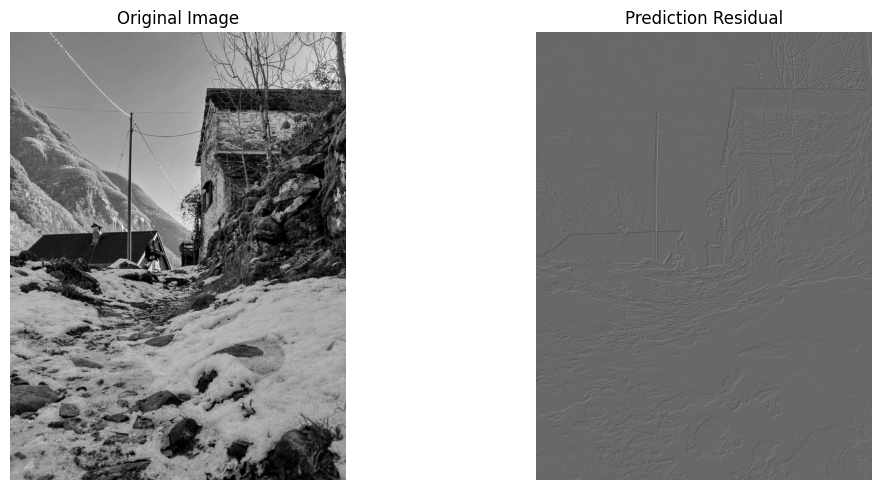

In [81]:
# 4.4 Predictive Coding and Redundancy

# Use your grayscale image
img_pred = img2_uint8.astype(np.float64)

# Predictor:
# X_hat(i,j) = 0.5 * (left + upper)
pred = np.zeros_like(img_pred)

pred[1:, 1:] = 0.5 * (
    img_pred[1:, :-1] +
    img_pred[:-1, 1:]
)

# Actual pixels corresponding to valid predictions
actual = img_pred[1:, 1:]

# Residual
residual = actual - pred[1:, 1:]


# Original image entropy
counts_orig, _ = np.histogram(
    img2_uint8,
    bins=256,
    range=(0, 256)
)

p_orig = counts_orig / counts_orig.sum()
H_original = entropy(p_orig)


# Residual entropy
residual_int = np.round(residual).astype(int)

res_min = residual_int.min()
res_max = residual_int.max()

counts_res, _ = np.histogram(
    residual_int,
    bins=np.arange(res_min, res_max + 2)
)

p_res = counts_res / counts_res.sum()
H_residual = entropy(p_res)


# Redundancy
R = 1 - (H_original / np.log2(256))


print("Original image entropy:", H_original)
print("Residual entropy:", H_residual)
print("Redundancy R:", R)


# Show original and residual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img2_uint8, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(residual, cmap='gray')
plt.title("Prediction Residual")
plt.axis("off")

plt.tight_layout()
plt.show()

In [82]:
# 4.4 Sequence Experiment: AR(1)

N = 100000
alpha = 0.9

X_ar = np.zeros(N, dtype=int)

# Initial value
X_ar[0] = 128

# Generate AR(1) sequence
for t in range(1, N):
    noise = np.random.normal(0, 10)

    value = alpha * X_ar[t - 1] + noise

    X_ar[t] = int(
        np.clip(
            np.round(value),
            0,
            255
        )
    )

# Entropy of original AR sequence
counts_ar = np.bincount(X_ar, minlength=256)
p_ar = counts_ar / counts_ar.sum()

H_ar = entropy(p_ar)

# Predict current value from previous value
pred_ar = alpha * X_ar[:-1]

# Residual
res_ar = X_ar[1:] - pred_ar
res_ar = np.round(res_ar).astype(int)

# Residual entropy
res_min = res_ar.min()
res_max = res_ar.max()

counts_res_ar, _ = np.histogram(
    res_ar,
    bins=np.arange(res_min, res_max + 2)
)

p_res_ar = counts_res_ar / counts_res_ar.sum()

H_res_ar = entropy(p_res_ar)

print("AR(1) sequence entropy:", H_ar)
print("AR(1) residual entropy:", H_res_ar)

AR(1) sequence entropy: 5.096781597832694
AR(1) residual entropy: 5.017658069003866


In [83]:
# Compare different alpha values

N = 100000
alpha_values = [0.2, 0.5, 0.9, 0.99]

for alpha in alpha_values:

    X_ar = np.zeros(N, dtype=int)
    X_ar[0] = 128

    for t in range(1, N):
        noise = np.random.normal(0, 10)

        value = alpha * X_ar[t - 1] + noise

        X_ar[t] = int(
            np.clip(
                np.round(value),
                0,
                255
            )
        )

    counts_ar = np.bincount(X_ar, minlength=256)
    p_ar = counts_ar / counts_ar.sum()

    H_ar = entropy(p_ar)

    pred_ar = alpha * X_ar[:-1]

    res_ar = X_ar[1:] - pred_ar
    res_ar = np.round(res_ar).astype(int)

    res_min = res_ar.min()
    res_max = res_ar.max()

    counts_res_ar, _ = np.histogram(
        res_ar,
        bins=np.arange(res_min, res_max + 2)
    )

    p_res_ar = counts_res_ar / counts_res_ar.sum()

    H_res_ar = entropy(p_res_ar)

    print(
        f"alpha={alpha} -> "
        f"H(X)={H_ar:.3f}, "
        f"H(residual)={H_res_ar:.3f}"
    )

alpha=0.2 -> H(X)=3.280, H(residual)=3.991
alpha=0.5 -> H(X)=3.678, H(residual)=4.322
alpha=0.9 -> H(X)=5.108, H(residual)=5.019
alpha=0.99 -> H(X)=7.027, H(residual)=5.279


In [ ]:
print(

)